# Concurrency Patterns in Python — A Derivatives-Pipeline Perspective

This notebook demonstrates the concurrency primitives used in
`basis-vol-lab` and when each one is appropriate.

| Pattern | Best For | GIL? | Used In |
|---------|----------|------|---------|
| `asyncio` | Network I/O (REST, WebSocket) | Releases during `await` | connectors, snapshot pipeline |
| `threading` | Mixed I/O + light CPU | Contention on CPU-bound work | comparison baseline |
| `ProcessPoolExecutor` | CPU-heavy batches | Bypassed (separate processes) | benchmark IV solver |
| NumPy vectorization | Array math | Released during C extensions | pricing, Greeks, RV |

> Re-run the notebook any time — Sections 2–3 hit the live Deribit REST
> API (public, no credentials). Sections 4–6 use synthetic data.

## 1 — Setup

In [1]:
import asyncio
import time
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

import httpx
import matplotlib.pyplot as plt
import numpy as np
from basis_analytics import black76_price, implied_vol_array

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 9,
    }
)

## 2 — Asyncio: I/O Concurrency

The snapshot pipeline fetches data from **Deribit** (BTC options, BTC
futures, ETH options, ETH futures) and **Binance** (funding, basis, OI)
concurrently. Each REST call takes 100–500 ms of network wait. Running
them sequentially would waste time the CPU could spend on other I/O.

The key insight: `asyncio` doesn't use threads or processes. It
multiplexes I/O on a **single thread** via an event loop. When one
coroutine `await`s a network response, the event loop runs another.

### Sequential vs concurrent REST fetches

We fetch four Deribit endpoints — two currencies × two asset kinds —
first sequentially, then with `asyncio.gather`.

In [2]:
DERIBIT_BASE = "https://www.deribit.com/api/v2"
ENDPOINTS = [
    ("BTC", "option"),
    ("BTC", "future"),
    ("ETH", "option"),
    ("ETH", "future"),
]


async def fetch_book_summary(
    client: httpx.AsyncClient, currency: str, kind: str
) -> dict:
    """Fetch a single book-summary page from Deribit."""
    r = await client.get(
        f"{DERIBIT_BASE}/public/get_book_summary_by_currency",
        params={"currency": currency, "kind": kind},
    )
    r.raise_for_status()
    return r.json()


async def sequential_fetch() -> list[dict]:
    results = []
    async with httpx.AsyncClient(timeout=15.0) as client:
        for currency, kind in ENDPOINTS:
            results.append(await fetch_book_summary(client, currency, kind))
    return results


async def concurrent_fetch() -> list[dict]:
    async with httpx.AsyncClient(timeout=15.0) as client:
        return await asyncio.gather(
            *(fetch_book_summary(client, c, k) for c, k in ENDPOINTS)
        )

In [3]:
# Sequential
t0 = time.perf_counter()
seq_results = await sequential_fetch()
seq_time = time.perf_counter() - t0

# Concurrent
t0 = time.perf_counter()
con_results = await concurrent_fetch()
con_time = time.perf_counter() - t0

speedup = seq_time / con_time
print(f"Sequential: {seq_time:.3f}s")
print(f"Concurrent: {con_time:.3f}s")
print(f"Speedup:    {speedup:.1f}×")
print(f"\nRecords fetched: {sum(len(r['result']) for r in con_results)}")

Sequential: 1.054s
Concurrent: 0.367s
Speedup:    2.9×

Records fetched: 1696


With four independent network calls, `asyncio.gather` typically
delivers a 3–4× speedup — the total wall time is bounded by the
**slowest** request, not the **sum** of all requests.

This is exactly how `_run_snapshot_async` in `apps/api/snapshot.py`
works:

```python
btc_task  = asyncio.create_task(_pull_deribit("BTC", asof))
eth_task  = asyncio.create_task(_pull_deribit("ETH", asof))
binance   = asyncio.create_task(_pull_binance(["BTCUSDT", "ETHUSDT"]))
(btc_opts, btc_futs), (eth_opts, eth_futs), binance = await asyncio.gather(
    btc_task, eth_task, binance_task
)
```

## 3 — Producer–Consumer with `asyncio.Queue`

Both the Deribit and Binance WebSocket clients use the same
architecture:

```
WebSocket frames  →  background task (producer)  →  asyncio.Queue  →  async iterator (consumer)
```

The **producer** runs in a background `asyncio.Task`, parsing incoming
frames and pushing parsed objects onto a bounded queue. The **consumer**
yields items via `async for`. If the consumer is slow, the bounded
queue (`maxsize=1024`) creates back-pressure.

Below is a simplified version of this pattern using synthetic data.

In [4]:
DONE = object()  # sentinel to signal end-of-stream


async def producer(queue: asyncio.Queue, n: int = 20) -> None:
    """Simulate a WebSocket stream producing ticks."""
    for i in range(n):
        await asyncio.sleep(0.05)  # simulate network latency
        price = 100_000 + np.random.normal(0, 500)
        await queue.put({"tick": i, "price": round(price, 2)})
    await queue.put(DONE)


async def consumer(queue: asyncio.Queue) -> list[dict]:
    """Consume ticks until DONE sentinel."""
    received = []
    while True:
        item = await queue.get()
        if item is DONE:
            break
        received.append(item)
    return received


queue: asyncio.Queue = asyncio.Queue(maxsize=8)
prod_task = asyncio.create_task(producer(queue, n=20))
ticks = await consumer(queue)
await prod_task

print(f"Received {len(ticks)} ticks")
print(f"First: {ticks[0]}")
print(f"Last:  {ticks[-1]}")

Received 20 ticks
First: {'tick': 0, 'price': 100176.74}
Last:  {'tick': 19, 'price': 99651.81}


### Reconnection with exponential backoff

Both WebSocket clients wrap the connection in a retry loop with
exponential backoff, capped at 30 seconds. This makes the stream
resilient to transient disconnects:

```python
backoff = 1.0
while True:
    try:
        async with websockets.connect(url) as ws:
            backoff = 1.0          # reset on success
            await self._consume(ws, queue)
    except (TimeoutError, ConnectionClosed, OSError):
        await asyncio.sleep(backoff)
        backoff = min(backoff * 2, max_backoff)  # 1→2→4→…→30s
```

## 4 — The GIL and CPU-Bound Work

Python's **Global Interpreter Lock** (GIL) means only one thread
executes Python bytecode at a time. For I/O-bound work this is fine —
threads release the GIL while waiting. For CPU-bound pure-Python work,
threads give zero parallel speedup and may even slow down due to lock
contention.

We demonstrate this with the IV solver, which is pure-Python
(`scipy.optimize.brentq` called in a loop).

In [5]:
# Build a synthetic option chain
rng = np.random.default_rng(42)
N = 500
F = np.full(N, 100_000.0)
K = rng.uniform(70_000, 130_000, N)
T = rng.uniform(0.02, 1.0, N)
sigma_true = rng.uniform(0.3, 1.2, N)
is_call = rng.choice([True, False], N)

prices = black76_price(F, K, T, sigma_true, is_call=is_call)
print(f"Chain size: {N} options")
print(f"Price range: {prices.min():.2f} – {prices.max():.2f}")

Chain size: 500 options
Price range: 0.37 – 53046.46


In [6]:
from _concurrency_helpers import solve_chunk


def chunk_args(n_chunks):
    """Split the chain into equal chunks."""
    chunk_size = max(1, N // n_chunks)
    chunks = []
    for s in range(0, N, chunk_size):
        e = min(s + chunk_size, N)
        chunks.append((prices[s:e], F[s:e], K[s:e], T[s:e], is_call[s:e]))
    return chunks

In [7]:
WORKERS = 4
REPEATS = 3

timings = {"Sequential": [], "Threaded": [], "Multiprocess": []}

for _ in range(REPEATS):
    # Sequential
    t0 = time.perf_counter()
    iv_seq = implied_vol_array(prices, F, K, T, is_call)
    timings["Sequential"].append(time.perf_counter() - t0)

    # ThreadPoolExecutor
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        thread_results = list(pool.map(solve_chunk, chunk_args(WORKERS)))
    iv_thr = np.concatenate(thread_results)
    timings["Threaded"].append(time.perf_counter() - t0)

    # ProcessPoolExecutor
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=WORKERS) as pool:
        proc_results = list(pool.map(solve_chunk, chunk_args(WORKERS)))
    iv_proc = np.concatenate(proc_results)
    timings["Multiprocess"].append(time.perf_counter() - t0)

# Verify correctness
assert np.allclose(iv_seq, iv_thr, equal_nan=True), "Threaded results differ!"
assert np.allclose(iv_seq, iv_proc, equal_nan=True), "Multiprocess results differ!"
print("All results match. ✓")

All results match. ✓


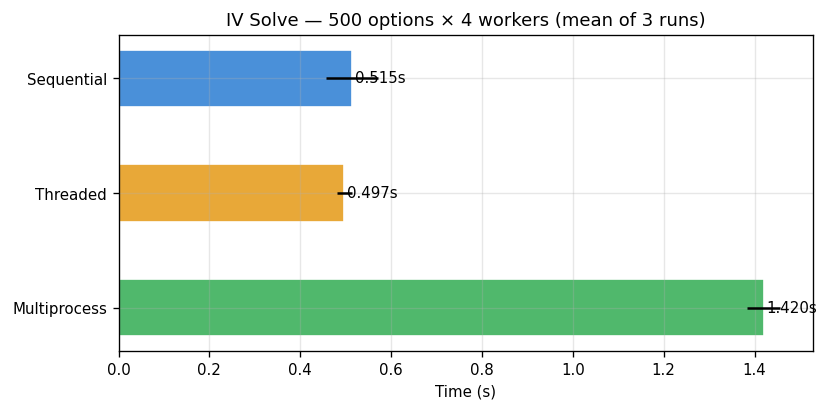

In [8]:
labels = list(timings.keys())
means = [np.mean(timings[k]) for k in labels]
stds = [np.std(timings[k]) for k in labels]
colors = ["#4a90d9", "#e8a838", "#50b86c"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(labels, means, xerr=stds, color=colors, edgecolor="white", height=0.5)
ax.set_xlabel("Time (s)")
ax.set_title(f"IV Solve — {N} options × {WORKERS} workers (mean of {REPEATS} runs)")
for bar, m in zip(bars, means, strict=True):
    ax.text(
        m + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{m:.3f}s",
        va="center",
        fontsize=9,
    )
ax.invert_yaxis()
fig.tight_layout()
plt.show()

### Interpreting the results

- **Threading ≈ Sequential** (or slower): the GIL serialises the
  pure-Python Brent loop. Thread creation and context-switch overhead
  add cost without parallel gain.
- **Multiprocess < Sequential**: each worker runs in its own process
  with its own GIL, achieving true parallelism. But there is
  **serialisation overhead** — the input arrays must be pickled,
  transferred, and unpickled. For small chains the overhead can exceed
  the compute savings.

> **Production choice**: `basis_analytics.iv.implied_vol_array` uses a
> simple Python loop. The network I/O to fetch option chains (~300 ms)
> dwarfs the IV solve (~50 ms for 500 options), so process-pool
> complexity isn't justified.

## 5 — Scaling: How Speedup Changes with Chain Size

The process-pool advantage grows with problem size because the
fixed serialisation overhead is amortised over more work per chunk.

In [9]:
SIZES = [100, 250, 500, 1_000, 2_000]
scaling = {"size": [], "sequential": [], "threaded": [], "multiprocess": []}

for size in SIZES:
    F_s = np.full(size, 100_000.0)
    K_s = rng.uniform(70_000, 130_000, size)
    T_s = rng.uniform(0.02, 1.0, size)
    sig_s = rng.uniform(0.3, 1.2, size)
    ic_s = rng.choice([True, False], size)
    p_s = black76_price(F_s, K_s, T_s, sig_s, is_call=ic_s)

    cs = max(1, size // WORKERS)
    chunks = [
        (
            p_s[s : min(s + cs, size)],
            F_s[s : min(s + cs, size)],
            K_s[s : min(s + cs, size)],
            T_s[s : min(s + cs, size)],
            ic_s[s : min(s + cs, size)],
        )
        for s in range(0, size, cs)
    ]

    # Sequential
    t0 = time.perf_counter()
    implied_vol_array(p_s, F_s, K_s, T_s, ic_s)
    t_seq = time.perf_counter() - t0

    # Threaded
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        list(pool.map(solve_chunk, chunks))
    t_thr = time.perf_counter() - t0

    # Multiprocess
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=WORKERS) as pool:
        list(pool.map(solve_chunk, chunks))
    t_proc = time.perf_counter() - t0

    scaling["size"].append(size)
    scaling["sequential"].append(t_seq)
    scaling["threaded"].append(t_thr)
    scaling["multiprocess"].append(t_proc)
    print(f"n={size:>5}: seq={t_seq:.3f}s  thr={t_thr:.3f}s  proc={t_proc:.3f}s")

n=  100: seq=0.103s  thr=0.110s  proc=1.541s


n=  250: seq=0.366s  thr=0.289s  proc=1.516s


n=  500: seq=0.538s  thr=0.606s  proc=1.432s


n= 1000: seq=1.097s  thr=1.141s  proc=1.623s


n= 2000: seq=2.222s  thr=2.389s  proc=2.084s


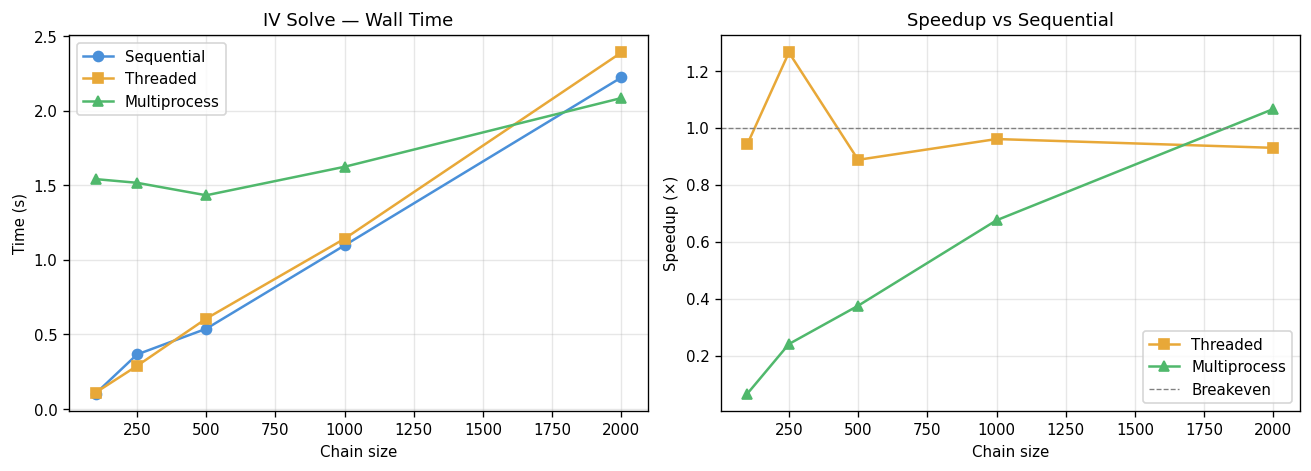

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Absolute times
ax1.plot(
    scaling["size"], scaling["sequential"], "o-", label="Sequential", color="#4a90d9"
)
ax1.plot(scaling["size"], scaling["threaded"], "s-", label="Threaded", color="#e8a838")
ax1.plot(
    scaling["size"],
    scaling["multiprocess"],
    "^-",
    label="Multiprocess",
    color="#50b86c",
)
ax1.set_xlabel("Chain size")
ax1.set_ylabel("Time (s)")
ax1.set_title("IV Solve — Wall Time")
ax1.legend()

# Speedup relative to sequential
seq_arr = np.array(scaling["sequential"])
ax2.plot(
    scaling["size"],
    seq_arr / np.array(scaling["threaded"]),
    "s-",
    label="Threaded",
    color="#e8a838",
)
ax2.plot(
    scaling["size"],
    seq_arr / np.array(scaling["multiprocess"]),
    "^-",
    label="Multiprocess",
    color="#50b86c",
)
ax2.axhline(1.0, color="grey", ls="--", lw=0.8, label="Breakeven")
ax2.set_xlabel("Chain size")
ax2.set_ylabel("Speedup (×)")
ax2.set_title("Speedup vs Sequential")
ax2.legend()

fig.tight_layout()
plt.show()

At small chain sizes the process-pool overhead dominates (speedup < 1×).
As the chain grows, multiprocess pulls ahead. Threading stays near 1×
regardless — the GIL prevents parallel execution of the Python-level
Brent loop.

## 6 — NumPy Vectorization: GIL-Free Parallelism

NumPy's C extensions **release the GIL** during array operations,
giving effective parallelism via BLAS/LAPACK threads without any
Python-level concurrency overhead.

Our `black76_price` and `black76_greeks` functions are fully
vectorized — they process entire option chains in one call:

```python
F_b, K_b, T_b, sig_b, df_b, call_b = np.broadcast_arrays(...)
d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
```

Let's compare vectorized pricing against a scalar Python loop.

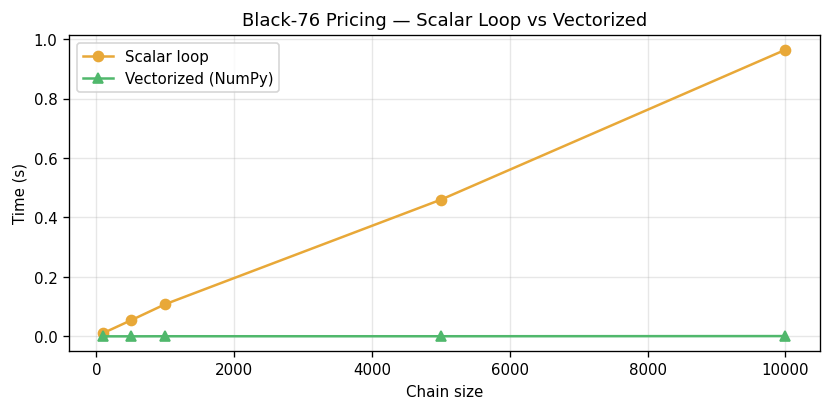


At n=10,000: vectorized is 949× faster


In [11]:
SIZES_VEC = [100, 500, 1_000, 5_000, 10_000]
vec_timing = {"size": [], "scalar_loop": [], "vectorized": []}

for size in SIZES_VEC:
    F_v = np.full(size, 100_000.0)
    K_v = rng.uniform(70_000, 130_000, size)
    T_v = rng.uniform(0.02, 1.0, size)
    sig_v = rng.uniform(0.3, 1.2, size)
    ic_v = rng.choice([True, False], size)

    # Scalar loop
    t0 = time.perf_counter()
    for i in range(size):
        float(black76_price(F_v[i], K_v[i], T_v[i], sig_v[i], is_call=bool(ic_v[i])))
    t_scalar = time.perf_counter() - t0

    # Vectorized
    t0 = time.perf_counter()
    black76_price(F_v, K_v, T_v, sig_v, is_call=ic_v)
    t_vec = time.perf_counter() - t0

    vec_timing["size"].append(size)
    vec_timing["scalar_loop"].append(t_scalar)
    vec_timing["vectorized"].append(t_vec)

# Plot
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(
    vec_timing["size"],
    vec_timing["scalar_loop"],
    "o-",
    label="Scalar loop",
    color="#e8a838",
)
ax.plot(
    vec_timing["size"],
    vec_timing["vectorized"],
    "^-",
    label="Vectorized (NumPy)",
    color="#50b86c",
)
ax.set_xlabel("Chain size")
ax.set_ylabel("Time (s)")
ax.set_title("Black-76 Pricing — Scalar Loop vs Vectorized")
ax.legend()
fig.tight_layout()
plt.show()

max_speedup = vec_timing["scalar_loop"][-1] / vec_timing["vectorized"][-1]
print(f"\nAt n={SIZES_VEC[-1]:,}: vectorized is {max_speedup:.0f}× faster")

## 7 — Putting It All Together

The production snapshot pipeline combines these patterns in a
three-layer architecture:

```
Layer 1 — I/O (asyncio)
┌──────────────────────────────────────────────┐
│  asyncio.gather(                             │
│      _pull_deribit("BTC"),   # REST fetch    │
│      _pull_deribit("ETH"),   # REST fetch    │
│      _pull_binance([...]),   # REST fetch    │
│  )                                           │
└──────────────────────────────────────────────┘
                    │
                    ▼
Layer 2 — Compute (vectorized NumPy)
┌──────────────────────────────────────────────┐
│  atm_term_structure(options)                 │
│  black76_greeks(F, K, T, sigma, ...)         │
│  close_to_close_rv(series, window)           │
│  annualized_carry(spot, futures, T)          │
└──────────────────────────────────────────────┘
                    │
                    ▼
Layer 3 — Persistence (sync I/O)
┌──────────────────────────────────────────────┐
│  Parquet write  →  R2 upload                 │
│  JSON serialize →  R2 upload                 │
│  SQLite/D1 metadata insert                   │
└──────────────────────────────────────────────┘
```

### Decision guide

| Bottleneck | Pattern | Why |
|-----------|---------|-----|
| Network wait (REST, WebSocket) | `asyncio` | Single-thread event loop; no GIL issue |
| Array math (pricing, Greeks, RV) | NumPy vectorization | C extensions release GIL; SIMD-friendly |
| Non-vectorizable CPU (Brent IV) | `ProcessPoolExecutor` | Bypass GIL; worth it only for large batches |
| Non-vectorizable CPU (small batch) | Sequential loop | Process-pool overhead exceeds compute savings |
| Mixed I/O + light CPU | `threading` | GIL released during I/O waits; fine for light CPU |

The key takeaway: **profile first, parallelize second**. In this
pipeline, network latency (~300 ms) dwarfs compute (~50 ms), so
`asyncio` for I/O and NumPy vectorization for compute is the optimal
combination. Process pools add complexity that is only justified at
batch sizes well beyond typical crypto option chains.